Plot a map showing Euler's jounrney from Basel to St Petersburg in 1727

Load the required libraries

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib_scalebar.scalebar import ScaleBar

Define Euler's waypoints

In [5]:
# Expanded route based on Euler's 1727 itinerary
euler_route = {
    "Basel": (7.58, 47.55),
    "Mainz": (8.27, 50.00),      # End of the Rhine boat leg
    "Frankfurt": (8.68, 50.11),
    "Kassel": (9.47, 51.31),     # Famous meeting with Wolff
    "Hannover": (9.73, 52.37),
    "Hamburg": (9.99, 53.55),
    "Lübeck": (10.68, 53.86),    # Port of departure for the Baltic
    "Reval": (24.75, 59.43),   # Tallinn
    "St. Petersburg": (30.33, 59.93)
}

lons = [coords[0] for coords in euler_route.values()]
lats = [coords[1] for coords in euler_route.values()]
city_names = list(euler_route.keys())

In [6]:
context_cities = {
    "London": (-0.12, 51.50),
    "Paris": (2.35, 48.85),
    "Berlin": (13.40, 52.52),
    "Copenhagen": (12.56, 55.67),
    "Stockholm": (18.06, 59.32),
    "Christiana": (10.75, 59.91), # Modern-day Oslo
    "Prague": (14.43, 50.07),
    "Warsaw": (21.01, 52.23),
    "Riga": (24.10, 56.94)
}

c_lons = [coords[0] for coords in context_cities.values()]
c_lats = [coords[1] for coords in context_cities.values()]

Plot a map, with the route.

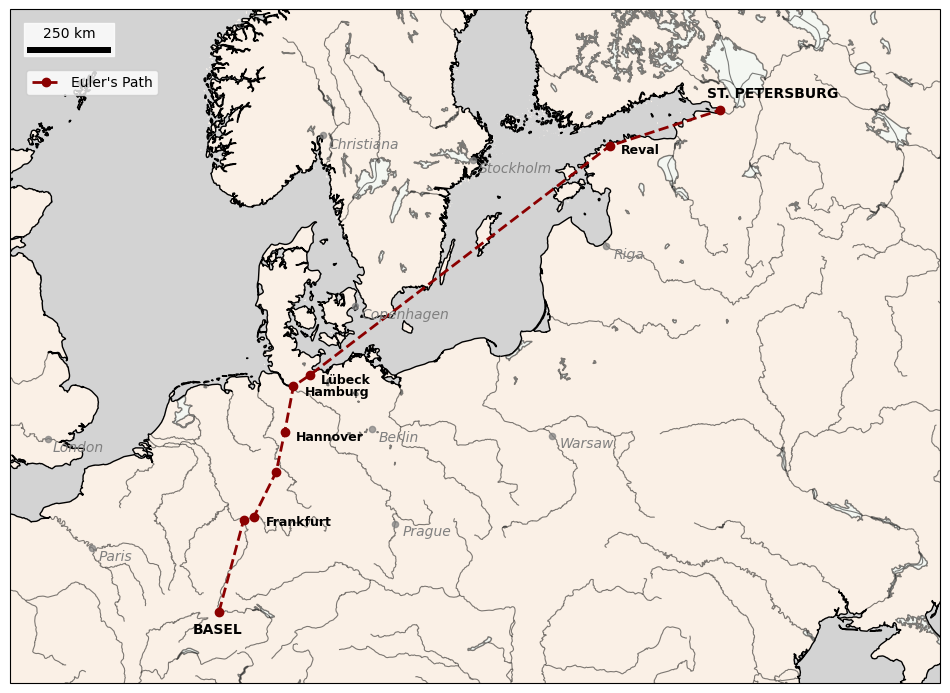

In [19]:
fig = plt.figure(figsize=(12, 10))

# 1. Create the map with a European focus
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=15, central_latitude=53))
ax.set_extent([0, 35, 45, 62], crs=ccrs.PlateCarree())

# 2. Add geographic features for a "vintage" feel
rivers = cfeature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '10m',
                edgecolor='black', facecolor='none', linewidth=0.8, alpha=0.5)
lakes = cfeature.NaturalEarthFeature('physical', 'lakes', '10m',
                edgecolor='black', facecolor='azure', alpha=0.5)
coastline = cfeature.NaturalEarthFeature('physical', 'coastline', '10m',
                edgecolor='black', facecolor='none', linewidth=1)
ocean = cfeature.NaturalEarthFeature('physical', 'ocean', '10m',
                                     facecolor='lightgrey')
land = cfeature.NaturalEarthFeature('physical', 'land', '10m', facecolor='linen')

ax.add_feature(ocean)
ax.add_feature(land)
ax.add_feature(lakes)
ax.add_feature(rivers)
ax.add_feature(coastline)
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)

# Plot Context Cities
ax.scatter(c_lons, c_lats, color='gray', s=20, alpha=0.7, 
           transform=ccrs.PlateCarree(), zorder=5)

# Add Labels for Context Cities
# Using a slightly smaller, italic font to distinguish from Euler's route
for name, (lon, lat) in context_cities.items():
    ax.text(lon + 0.3, lat - 0.3, name, transform=ccrs.PlateCarree(), 
            fontsize=10, color='gray', style='italic', zorder=6)
    
# 3. Plot the route line
# transform=ccrs.Geodetic() ensures the lines follow the curvature of the Earth
ax.plot(lons, lats, color='darkred', linewidth=2, marker='o', linestyle = '--',
        transform=ccrs.Geodetic(), label="Euler's Path")

# Highlight Euler's Start and End
ax.text(7.58, 47.0, "BASEL", transform=ccrs.PlateCarree(), 
        fontsize=10, fontweight='bold', color='black', ha='center')
ax.text(33, 60., "ST. PETERSBURG", transform=ccrs.PlateCarree(), 
        fontsize=10, fontweight='bold', color='black', ha='center')

# 4. Label the cities
for name in ["Hamburg", "Reval", "Frankfurt", "Hannover", "Lübeck"]:
    lon, lat = euler_route[name]
    ax.text(lon + 0.5, lat-0.2, name, transform=ccrs.Geodetic(), 
            fontsize=9, fontweight='bold')

# Create the scale bar with fixed length and specific ticks
scalebar = ScaleBar(
    1, 
    units="m", 
    location="upper left", 
    fixed_value=250,        # Total length
    fixed_units="km",       # Units
    box_alpha=0.8, 
    border_pad=1,
    scale_loc="top"
)

ax.add_artist(scalebar)

ax.legend(loc='upper left', bbox_to_anchor=(0.01, 0.92), 
          fontsize=10, frameon=True, facecolor='white', framealpha=0.8)

#plt.title("Leonhard Euler's Journey: Basel to St. Petersburg (1727)", fontsize=14)
plt.savefig("Euler_1727.png")
